# Embedding-Based Fashion Recommendation Prototype

## 1. Objective

The objective of this notebook is to improve the first rule-based recommendation prototype by adding visual similarity.

The previous recommendation prototype used a simple rule:

- predict the style of the input item
- predict the clothing type of the input item
- retrieve items with the same style and a different clothing type
- randomly select one item per missing clothing type

This notebook improves that approach by using `image embeddings`. Instead of selecting random items, the system extracts visual feature vectors from images and ranks candidate recommendations by similarity to the input item.

The goal is to recommend items that are:

- from the same predicted style
- from a different clothing type
- visually similar to the input item based on learned image features

## 2. Project Context

The rule-based recommendation prototype showed that combining style prediction and clothing type prediction can produce basic outfit suggestions. However, the recommendations were selected randomly from the filtered catalogue.

This means that the selected items were not ranked based on visual compatibility. For example, the system could recommend items from the correct style category, but it did not consider whether they matched the input image in terms of color, texture, shape, or general visual appearance.

To improve this, this notebook uses embeddings extracted from a pretrained ResNet34 model. These embeddings represent each image as a numerical feature vector. Images with similar visual features should have embeddings that are closer together.

By ranking candidate items using cosine similarity, the recommender becomes more controlled and more explainable than the random rule-based version.

## 3. Approach

The embedding-based recommendation process follows these steps:

1. Load the trained style and clothing type classifiers.
2. Build a catalogue from the cleaned dataset.
3. Use a ResNet34 feature extractor to generate embeddings for all catalogue images.
4. Predict the style and clothing type of the input image.
5. Generate an embedding for the input image.
6. Filter the catalogue to items with the same predicted style and a different clothing type.
7. Rank candidates by cosine similarity to the input image.
8. Select the most similar item from each missing clothing type.

This keeps the simple logic from the first recommender, but improves the selection process by replacing random sampling with similarity ranking.

## 4. Import Libraries

In [17]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.metrics.pairwise import cosine_similarity

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

Using device: CUDA


## 5. Load Models and Feature Extractor

This notebook uses two types of models:

- the trained classifiers (style and clothing type)
- a feature extractor for computing image embeddings

The classifiers are used to determine the style and clothing type of the input image.

The feature extractor is based on ResNet34, but instead of using the final classification layer, the network is truncated so that it outputs feature vectors. These vectors represent the visual content of the image and are used for similarity comparison.

### 5.1. Load Classifiers

In [3]:
style_model_path = "../models/style_resnet34.pth"
type_model_path = "../models/type_resnet34.pth"

style_checkpoint = torch.load(style_model_path, map_location=device)
type_checkpoint = torch.load(type_model_path, map_location=device)

style_class_names = style_checkpoint["class_names"]
type_class_names = type_checkpoint["class_names"]

print("Style classes:", style_class_names)
print("Type classes:", type_class_names)

Style classes: ['formal', 'gothic', 'sporty', 'streetwear']
Type classes: ['jacket', 'pants', 'shoes', 'tshirt']


In [4]:
def load_resnet34_classifier(checkpoint, num_classes):
    model = models.resnet34(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()
    return model

style_model = load_resnet34_classifier(style_checkpoint, len(style_class_names))
type_model = load_resnet34_classifier(type_checkpoint, len(type_class_names))

print("Models loaded successfully.")

Models loaded successfully.


### 5.2. Create Feature Extractor

To compute embeddings, the final classification layer of ResNet34 is removed. The remaining network outputs a feature vector that represents the image.

This vector is used to measure similarity between images using cosine similarity.

In [5]:
resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# Remove final classification layer
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("Feature extractor ready.")

Feature extractor ready.


### 5.3. Define Image Transform for Embeddings

In [6]:
embedding_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 5.4. Embedding Function

This function converts an image into a feature vector using the feature extractor.

In [7]:
def get_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = embedding_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = feature_extractor(input_tensor)
        features = features.view(features.size(0), -1)  # flatten

        # normalize for cosine similarity
        features = F.normalize(features, p=2, dim=1)

    return features.cpu().numpy()[0]

### 5.5. Test embedding

In [8]:
test_image_path = "../dataset/cleaned/gothic/jacket/gothic_jacket_025.png"

embedding = get_image_embedding(test_image_path)

print("Embedding shape:", embedding.shape)

Embedding shape: (512,)


## 6. Build Catalogue with Embeddings

The recommender needs a searchable catalogue of images. Each catalogue item stores:

- image path
- known style
- known clothing type
- filename
- image embedding

The embedding is the numerical representation used to compare visual similarity between the input image and possible recommendations.

### 6.1. Build Catalogue DataFrame

In [10]:
catalogue_root = "../dataset/cleaned"

catalogue_items = []

for style in sorted(os.listdir(catalogue_root)):
    style_path = os.path.join(catalogue_root, style)

    if not os.path.isdir(style_path):
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = os.path.join(style_path, item_type)

        if not os.path.isdir(type_path):
            continue

        for filename in sorted(os.listdir(type_path)):
            image_path = os.path.join(type_path, filename)

            if os.path.isfile(image_path):
                catalogue_items.append({
                    "image_path": image_path,
                    "style": style,
                    "type": item_type,
                    "filename": filename
                })

catalogue_df = pd.DataFrame(catalogue_items)

print("Catalogue size:", len(catalogue_df))
# catalogue_df.head()

Catalogue size: 800


### 6.2. Generate Embeddings

In [11]:
catalogue_embeddings = []

for image_path in catalogue_df["image_path"]:
    embedding = get_image_embedding(image_path)
    catalogue_embeddings.append(embedding)

catalogue_embeddings = np.vstack(catalogue_embeddings)

print("Catalogue embeddings shape:", catalogue_embeddings.shape)

Catalogue embeddings shape: (800, 512)


### 6.3. Attach Embeddings to Catalogue

The embeddings are stored in a separate NumPy array because each embedding is a vector. To keep the catalogue and embedding matrix aligned, the row index of the catalogue is used as the embedding index.

In [12]:
catalogue_df = catalogue_df.reset_index(drop=True)
catalogue_df["embedding_index"] = catalogue_df.index

catalogue_df.head()

,image_path,style,type,filename,embedding_index
0,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_001.png,0
1,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_002.png,1
2,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_003.png,2
3,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_004.png,3
4,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_005.png,4


### 6.4 Check Catalogue Distribution

Before using the catalogue for recommendations, the style and clothing type distribution is checked to confirm that the retrieval pool is balanced.

In [13]:
catalogue_distribution = pd.crosstab(catalogue_df["style"], catalogue_df["type"])
catalogue_distribution

type,jacket,pants,shoes,tshirt
style,,,,
formal,50,50,50,50
gothic,50,50,50,50
sporty,50,50,50,50
streetwear,50,50,50,50


## 7. Prediction Function

Before recommending items, the system predicts the style and clothing type of the input image using the two trained classifiers.

These predictions are used to filter the catalogue before applying embedding similarity.

In [14]:
def predict_style_and_type(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = embedding_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        style_outputs = style_model(input_tensor)
        type_outputs = type_model(input_tensor)

        style_probs = torch.softmax(style_outputs, dim=1)
        type_probs = torch.softmax(type_outputs, dim=1)

        style_pred_idx = torch.argmax(style_probs, dim=1).item()
        type_pred_idx = torch.argmax(type_probs, dim=1).item()

        predicted_style = style_class_names[style_pred_idx]
        predicted_type = type_class_names[type_pred_idx]

        style_confidence = style_probs[0][style_pred_idx].item()
        type_confidence = type_probs[0][type_pred_idx].item()

    return {
        "style": predicted_style,
        "type": predicted_type,
        "style_confidence": style_confidence,
        "type_confidence": type_confidence
    }

## 8. Embedding-Based Recommendation Function

The recommendation function combines classification and embedding similarity.

The function follows these steps:

1. Predict the style and clothing type of the input image.
2. Generate an embedding for the input image.
3. Filter the catalogue to items with the same predicted style and a different clothing type.
4. Compute cosine similarity between the input embedding and candidate embeddings.
5. Select the most similar item from each remaining clothing type.

This improves the previous rule-based recommender by replacing random selection with similarity-based ranking.

In [18]:
def recommend_items_by_embedding(image_path, catalogue_df, catalogue_embeddings):
    prediction = predict_style_and_type(image_path)

    predicted_style = prediction["style"]
    predicted_type = prediction["type"]

    input_embedding = get_image_embedding(image_path)

    candidates = catalogue_df[
        (catalogue_df["style"] == predicted_style) &
        (catalogue_df["type"] != predicted_type)
    ].copy()

    if len(candidates) == 0:
        return prediction, candidates

    candidate_indices = candidates["embedding_index"].values
    candidate_embeddings = catalogue_embeddings[candidate_indices]

    similarities = cosine_similarity(
        candidate_embeddings,
        input_embedding.reshape(1, -1)
    ).flatten()

    candidates["similarity"] = similarities

    recommended_rows = []

    for item_type in sorted(candidates["type"].unique()):
        type_candidates = candidates[candidates["type"] == item_type]
        top_item = type_candidates.sort_values("similarity", ascending=False).head(1)
        recommended_rows.append(top_item)

    recommendations = pd.concat(recommended_rows).sort_values(
        "similarity",
        ascending=False
    )

    return prediction, recommendations

### 8.1 Test the Recommendation Function

The function is tested with one example input image. The output should contain one recommendation for each missing clothing type, ranked by visual similarity.

In [22]:
test_image_path = "../dataset/cleaned/sporty/jacket/sporty_jacket_025.png"

prediction, recommendations = recommend_items_by_embedding(
    test_image_path,
    catalogue_df,
    catalogue_embeddings
)

print("Prediction:")
print(prediction)

recommendations

Prediction:
{'style': 'sporty', 'type': 'jacket', 'style_confidence': 0.8333853483200073, 'type_confidence': 0.9791852831840515}


,image_path,style,type,filename,embedding_index,similarity
570,../dataset/cleaned\sporty\tshirt\sporty_tshirt...,sporty,tshirt,sporty_tshirt_021.png,570,0.818866
454,../dataset/cleaned\sporty\pants\sporty_pants_0...,sporty,pants,sporty_pants_005.png,454,0.727605
520,../dataset/cleaned\sporty\shoes\sporty_shoes_0...,sporty,shoes,sporty_shoes_021.png,520,0.529032


## 9. Visualizing Recommendations

To better understand the recommendation results, the input image and the retrieved items are displayed together.

This makes it easier to evaluate whether the recommendations are visually similar and appropriate for the predicted style and clothing type.

In [23]:
def show_recommendations(image_path, prediction, recommendations):
    num_recs = len(recommendations)

    fig, axes = plt.subplots(1, num_recs + 1, figsize=(5 * (num_recs + 1), 5))

    # Input image
    input_image = Image.open(image_path).convert("RGB")
    axes[0].imshow(input_image)
    axes[0].set_title(
        f"Input\nStyle: {prediction['style']} ({prediction['style_confidence']:.2f})\n"
        f"Type: {prediction['type']} ({prediction['type_confidence']:.2f})"
    )
    axes[0].axis("off")

    # Recommendations
    for i, (_, row) in enumerate(recommendations.iterrows()):
        rec_image = Image.open(row["image_path"]).convert("RGB")
        axes[i + 1].imshow(rec_image)
        axes[i + 1].set_title(
            f"{row['style']} {row['type']}\nSim: {row['similarity']:.2f}"
        )
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

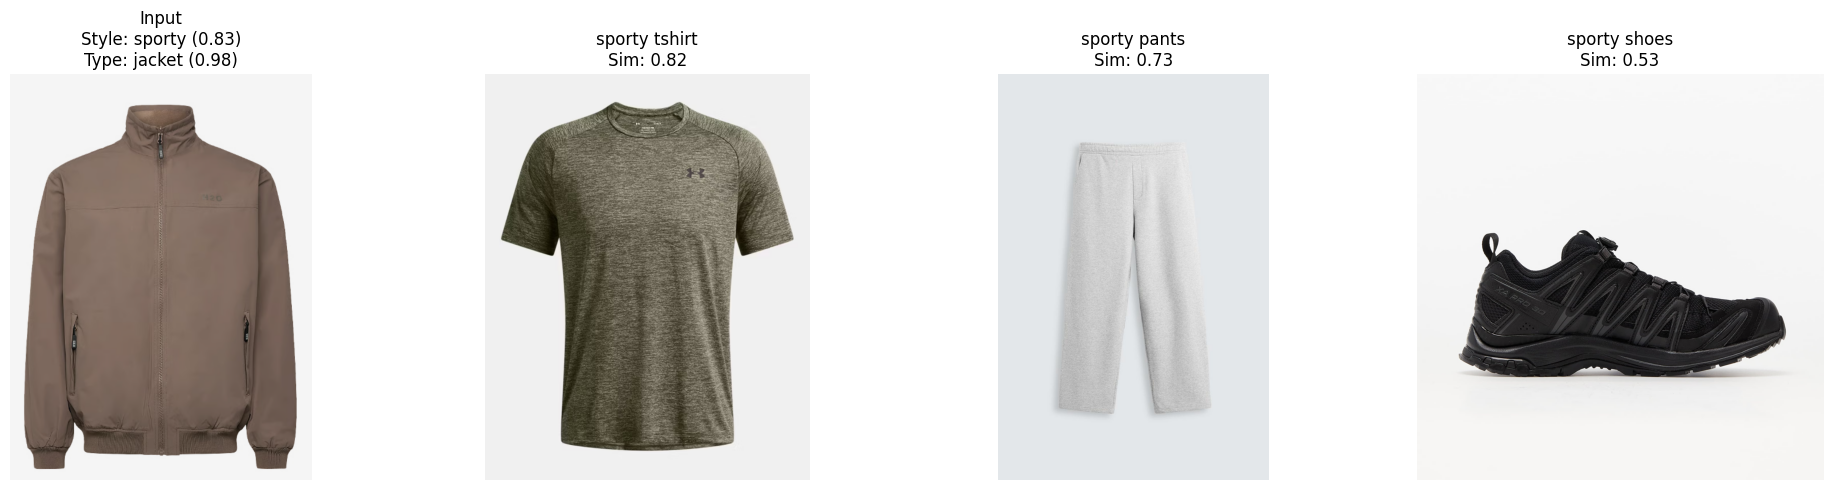

In [ ]:
show_recommendations(test_image_path, prediction, recommendations)

## 10. Results Interpretation

The embedding-based recommendation system successfully combines classification and visual similarity to produce more meaningful outfit suggestions.

For a given input image, the system first predicts the clothing type and style. It then retrieves candidate items that match the predicted style while excluding the same clothing type. These candidates are ranked using cosine similarity between image embeddings.

The results show that the recommended items are not only consistent in style, but also visually similar to the input item. Items with higher similarity scores tend to share more detailed visual characteristics such as color, texture, and overall design.

Compared to the earlier rule-based recommendation approach, which selected items randomly within a style, this method provides a more structured and explainable ranking. The similarity scores offer a clear indication of why certain items are recommended over others.

Overall, the system demonstrates that embedding-based retrieval is effective for improving recommendation quality in fashion applications.

## 11. Limitations

Despite the improvements, several limitations remain in the current approach.

First, the dataset is still relatively small and manually curated. This limits the diversity of items and may reduce generalization to real-world fashion data.

Second, the embedding model is based on a pretrained ResNet34 that was not fine-tuned specifically for fashion similarity. As a result, the embeddings capture general visual features but may not fully represent subtle style relationships.

Third, the recommendation logic enforces strict rules, such as selecting only items of the same predicted style. In practice, outfits may include items from multiple styles, which is not yet supported.

Finally, the system does not consider other important factors such as color compatibility, seasonality, or user preferences. These aspects would be necessary for a more complete recommendation system.

## 12. Conclusion

This notebook presented an improved recommendation prototype based on embedding similarity.

By combining style and clothing type classification with embedding-based retrieval, the system is able to generate outfit recommendations that are both structurally valid and visually coherent.

The results show a clear improvement over the previous rule-based approach. Instead of selecting items randomly, the system ranks candidates based on visual similarity, resulting in more consistent and explainable recommendations.

This experiment demonstrates that embedding-based methods are a strong foundation for fashion recommendation systems. In future work, the model can be improved through dataset expansion, fine-tuning, and more advanced recommendation strategies.

## 13. Saving the results

### 13.1. Saving the recommendation summary

In [25]:
embedding_recommendation_summary = {
    "experiment": "embedding_based_recommendation",
    "input_image": test_image_path,
    "predicted_style": prediction["style"],
    "predicted_type": prediction["type"],
    "style_confidence": prediction["style_confidence"],
    "type_confidence": prediction["type_confidence"],
    "recommendation_rule": "same predicted style, different clothing type, one item per missing type",
    "ranking_method": "cosine similarity using ResNet34 image embeddings",
    "num_recommendations": len(recommendations)
}

pd.DataFrame([embedding_recommendation_summary]).to_csv(
    "../results/recommendation_embedding_based/embedding_recommendation_summary.csv",
    index=False
)

### 13.2. Saving the recommended items

In [26]:
recommendations.to_csv(
  "../results/recommendation_embedding_based/embedding_recommended_items_example.csv",
  index=False
)

### 13.3. Saving the catalogue distribution

In [27]:
catalogue_distribution.to_csv(
  "../results/recommendation_embedding_based/catalogue_distribution.csv"
)

### 13.4. Saving the catalogue index

In [28]:
catalogue_df.to_csv(
  "../results/recommendation_embedding_based/catalogue_index.csv",
  index=False
)

### 13.5. Saving the catalogue embeddings

In [29]:
np.save(
  "../results/recommendation_embedding_based/catalogue_embeddings.npy",
  catalogue_embeddings
)